In [ ]:
from pathlib import Path
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Ejecución en local")

# TENER EN CUENTA DESDE DÓNDE ESTAMOS EJECUTANDO PARA ENCONTRAR EL REQUIREMENTS
BASE_PATH = Path("/content/drive/MyDrive/TFMCode") if IN_COLAB else Path("..").resolve()

if IN_COLAB:
    drive.mount('/content/drive')
    print("Ejecución en colab")

    %pip install -r "{BASE_PATH}/requirements.txt"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ejecución en colab


In [ ]:
# imports
# librerías
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import numpy as np
import sys
from pathlib import Path
# útiles
UTILS_PATH = BASE_PATH / "utils"
sys.path.append(str(UTILS_PATH))
# data
DATA_PATH = BASE_PATH / "data"
sys.path.append(str(DATA_PATH))
# clase y función del archivo py de la carpeta utils
from protocolo_evaluacion import (PerformanceEvaluator, run_benchmarked_inference)

# Implementación del sistema de referencia kNN

En este notebook implementaremos el código para conseguir los sistemas de referencia más óptimos posibles para los dos datasets MAN1 y UJI1. El modelo kNN se compone de tres elementos principales, que son, por orden de importancia: el valor de k, la función de distancia y la representación de los datos. Para conseguir la combinación más óptima de estos tres parámetros realizaremos una búsqueda de rejilla.

La función tune_knn_baseline realiza la búsqueda de rejilla para encontrar los mejores hiperparámetros del kNN en cada dataset. La búsqueda se hace entre los valores impares de k en el rango [1,15] y las métricas euclídea y manhattan

In [9]:
def tune_knn_baseline(dataset_name, x_train, y_train, x_test, y_test, iterations):
    """
    Realiza una búsqueda de los mejores hiperparámetros para el baseline k-NN.
    y_train/y_test deben contener todas las columnas necesarias (x, y, [piso, edificio])
    """
    k_values = [1, 3, 5, 7, 9, 11, 13, 15]
    metrics = ['euclidean', 'manhattan']

    best_results = None
    best_mae = float('inf')
    all_logs = []

    print(f"Búsqueda rejilla para el dataset: {dataset_name}")

    for metric in metrics:
        for k in k_values:
            # instanciamos el modelo kNN
            knn = KNeighborsRegressor(n_neighbors=k, metric=metric, weights='uniform')

            # ejecutamos la inferencia con el número de iteraciones indicado
            # llamamos a la función importada de utils
            # retorna las predicciones, el tiempo medio y el tiempo estándar de inferencia
            y_pred, avg_time, std_time = run_benchmarked_inference(knn.fit(x_train, y_train), x_test, iterations=iterations)

            # instanciamos un objeto de la clase evaluador importada de utils
            evaluator = PerformanceEvaluator(dataset_name)

            if dataset_name == "UJI1":
                # forzamos la conversión a array de np para poder hacer el slicing
                y_test_arr = y_test.values if isinstance(y_test, pd.DataFrame) else np.asarray(y_test)
                y_pred_arr = np.asarray(y_pred)
                # recordamos que nuestro target se compone de: x, y, z, piso, edificio
                # en UJI1 los índices 0 y 1 son x e y; el índice 3 es el piso; el índice 4 es el edificio
                # recordamos que los slicing funcionan como el primer valor incluido, el segundo valor excluido
                # y que el índice inicial es el 0
                # redondeamos
                y_pred_labels = np.round(y_pred_arr[:, [4, 3]])
                # llamamos al método del objeto
                # para UJI1 retorna accuracy de piso y edificio, MAE en 2D, percentiles 75 y 95
                res = evaluator.calculate_precision(y_test_arr[:, 0:2], y_pred_arr[:, 0:2],
                                                   building_floor_true=y_test_arr[:, [4, 3]],
                                                   building_floor_pred=y_pred_labels)
            else:
                # para MAN1 retorna MAE en 2D, percentiles 75 y 95
                res = evaluator.calculate_precision(y_test, y_pred)

            # registra los resultados de eficiencia
            # añade a la lista de logs toda la información
            res['k'] = k
            res['metric'] = metric
            res['MTQ_ms'] = (avg_time / len(x_test)) * 1000

            all_logs.append(res)

            # criterio de selección del mejor modelo: el menor MAE (en UJI1, MAE cuando se acierta edificio/piso)
            if res['MAE_2D'] < best_mae:
                best_mae = res['MAE_2D']
                best_results = res

            # imprime información de la iteración en curso
            print(f"Prueba: k={k}, métrica={metric} --> MAE: {res['MAE_2D']:.2f}m")

    # retorna la información del método de cálculo de precisión en forma de df y los resultados del mejor modelo
    return pd.DataFrame(all_logs), best_results

## MAN1

Comenzamos a modelar nuestros sistemas de referencia para cada dataset. Procedemos a hacer el grid search, en primer lugar, con el dataset MAN1

In [ ]:
# importamos los archivos de train y test de RSS y de coordenadas
man1_train_rss = pd.read_csv(DATA_PATH / "clean" / "MAN1" / "MAN1_trnrss_clean.csv", header=None)
man1_test_rss = pd.read_csv(DATA_PATH / "clean" / "MAN1" / "MAN1_tstrss_clean.csv", header=None)
man1_train_crd = pd.read_csv(DATA_PATH / "clean" / "MAN1" / "MAN1_trncrd_clean.csv", header=None)
man1_test_crd = pd.read_csv(DATA_PATH / "clean" / "MAN1" / "MAN1_tstcrd_clean.csv", header=None)

In [ ]:
# llamamos a la función para afinar el kNN
# almacenamos en variables el retorno de la función: la información del cálculo de la precisión de todas las iteraciones y de la mejor configuración
# indicamos el número de iteraciones a probar
man1_log_df, man1_best_config = tune_knn_baseline("MAN1", man1_train_rss, man1_train_crd, man1_test_rss, man1_test_crd, iterations=5)

Búsqueda rejilla para el dataset: MAN1
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 43.36 ms, desviación: 13.13 ms
Prueba: k=1, métrica=euclidean --> MAE: 2.85m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 36.76 ms, desviación: 2.02 ms
Prueba: k=3, métrica=euclidean --> MAE: 2.52m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 38.55 ms, desviación: 3.25 ms
Prueba: k=5, métrica=euclidean --> MAE: 2.34m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 37.91 ms, desviación: 0.64 ms
Prueba: k=7, métrica=euclidean --> MAE: 2.30m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 44.46 ms, desviación: 7.30 ms
Prueba: k=9, métrica=euclidean --> MAE: 2.27m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 41.27 ms, desviación: 2.65 ms
Prueba: k=11, métrica=euclidean --> MAE: 2.27m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 41.90 ms, desviación: 2.17 ms
Prueba: k=13, métrica=euclidean --> MAE: 2.26m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 43.32 ms, 

Una vez que hemos llamado a la función para afinar el kNN podemos ver la información sobre las iteraciones realizadas y sobre la mejor combinación de hiperparámetros encontrada.

In [ ]:
# imprimimos la mejor configuración encontrada
print("Mejor modelo encontrado para MAN1. Métricas de precisión y mejores hiperparámetros")
print(man1_best_config)

# imprimimos df con la información sobre las iteraciones, ordenada de mejor MAE en 2D a peor
man1_log_df.sort_values(by='MAE_2D', ascending=True)

Mejor modelo encontrado para MAN1. Métricas de precisión y mejores hiperparámetros
{'MAE_2D': 2.1573793196057105, 'P75': 2.9737586299335006, 'P95': 4.6940073349266775, 'k': 15, 'metric': 'manhattan', 'MTQ_ms': 0.6700044092924698}


,MAE_2D,P75,P95,k,metric,MTQ_ms
15,2.157379,2.973759,4.694007,15,manhattan,0.670004
13,2.173722,2.881539,4.637918,11,manhattan,0.528141
12,2.192849,2.923038,4.604190,9,manhattan,0.428477
14,2.193223,2.994221,4.655502,13,manhattan,0.676988
11,2.215664,2.998997,4.826209,7,manhattan,0.420292
10,2.257887,3.065923,5.063099,5,manhattan,0.417695
6,2.262949,3.145199,4.974516,13,euclidean,0.091086
5,2.266056,3.174762,4.927744,11,euclidean,0.089720
4,2.269449,3.035346,5.125196,9,euclidean,0.096662
7,2.270413,3.077549,5.014729,15,euclidean,0.094168


Una vez que hemos obtenido la mejor combinación de hiperparámetros para MAN1 podemos entrenar a nuestro modelo que servirá como sistema de referencia definitivo para MAN1

In [ ]:
# almacenamos en variables los mejores valores de k y de métrica
man1_best_k = man1_best_config['k']
man1_best_metric = man1_best_config['metric']

# instanciamos el modelo configurado con los mejores hiperparámetros
man1_knn_best = KNeighborsRegressor(n_neighbors=man1_best_k, metric=man1_best_metric, weights='uniform')

# entrenamos
man1_knn_best.fit(man1_train_rss, man1_train_crd)

# predecimos test
man1_y_pred_best = man1_knn_best.predict(man1_test_rss)

# y_test es el dataframe original de coordenadas de test
man1_y_test = man1_test_crd.values

Con el modelo con los mejores hiperparámetros posibles entrenado y las predicciones sobre test hechas, podemos sacar toda la información sobre métricas que necesitamos para establecer el rendimiento de nuestro sistema de referencia que tendremos que batir en futuros modelos.

MÉTRICAS FINALES DEL BASELINE DE MAN1
MAE_2D: 2.1574
P75: 2.9738
P95: 4.6940

Curva de función de distribución acumulada MAN1


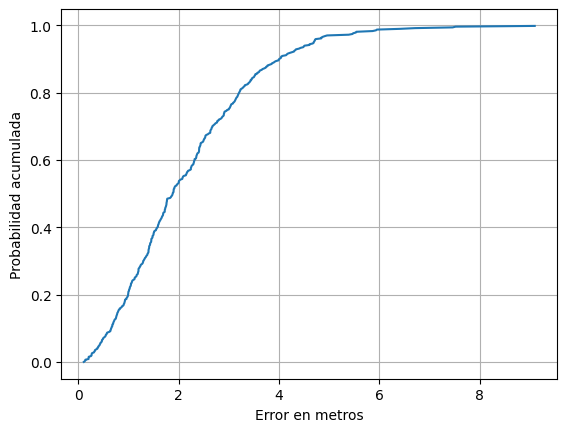

In [ ]:
# instanciamos un objeto de la clase evaluador
man1_final_evaluator = PerformanceEvaluator("MAN1")

# calculamos todas las métricas de precisión con las predicciones sobre test del modelo final
man1_final_metrics = man1_final_evaluator.calculate_precision(man1_y_test, man1_y_pred_best)

# imprimimos todas las métricas finales
print("MÉTRICAS FINALES DEL BASELINE DE MAN1")
for metrica, valor in man1_final_metrics.items():
    print(f"{metrica}: {valor:.4f}")

# generamos la visualización de la curva de error
print("\nCurva de función de distribución acumulada MAN1")
man1_final_evaluator.plot_cdf()

## UJI1

Una vez conseguido el sistema de referencia para MAN1, procedemos a hacer lo mismo con UJI1

In [ ]:
# importamos los archivos de train y test de RSS y de coordenadas
uji1_train_rss = pd.read_csv(DATA_PATH / "clean" / "UJI1" / "UJI1_trnrss_clean.csv", header=None)
uji1_test_rss = pd.read_csv(DATA_PATH / "clean" / "UJI1" / "UJI1_tstrss_clean.csv", header=None)
uji1_train_crd = pd.read_csv(DATA_PATH / "clean" / "UJI1" / "UJI1_trncrd_clean.csv", header=None)
uji1_test_crd = pd.read_csv(DATA_PATH / "clean" / "UJI1" / "UJI1_tstcrd_clean.csv", header=None)

In [10]:
# llamamos a la función para afinar el kNN
# almacenamos en variables el retorno de la función: la información del cálculo de la precisión de todas las iteraciones y de la mejor configuración
# indicamos el número de iteraciones a probar
uji1_log_df, uji1_best_config = tune_knn_baseline("UJI1", uji1_train_rss, uji1_train_crd, uji1_test_rss, uji1_test_crd, iterations=5)

Búsqueda rejilla para el dataset: UJI1
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 571.18 ms, desviación: 17.57 ms
Prueba: k=1, métrica=euclidean --> MAE: 7.92m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 805.78 ms, desviación: 124.49 ms
Prueba: k=3, métrica=euclidean --> MAE: 7.45m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 691.33 ms, desviación: 141.10 ms
Prueba: k=5, métrica=euclidean --> MAE: 7.34m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 583.21 ms, desviación: 7.09 ms
Prueba: k=7, métrica=euclidean --> MAE: 7.33m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 599.96 ms, desviación: 6.13 ms
Prueba: k=9, métrica=euclidean --> MAE: 7.50m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 663.61 ms, desviación: 117.99 ms
Prueba: k=11, métrica=euclidean --> MAE: 7.58m
Iniciando benchmark: 5 iteraciones...
Tiempo medio: 860.70 ms, desviación: 148.46 ms
Prueba: k=13, métrica=euclidean --> MAE: 7.60m
Iniciando benchmark: 5 iteraciones...
Tiempo me

In [11]:
# imprimimos la mejor configuración encontrada
print("Mejor modelo encontrado para UJI1. Métricas de precisión y mejores hiperparámetros")
print(uji1_best_config)

# imprimimos df con la información sobre las iteraciones, ordenada de mejor MAE en 2D a peor
uji1_log_df.sort_values(by='MAE_2D', ascending=True)

Mejor modelo encontrado para UJI1. Métricas de precisión y mejores hiperparámetros
{'Building_Accuracy': 98.82988298829883, 'Floor_Accuracy': 88.11881188118812, 'MAE_2D': 7.217972828933337, 'P75': 10.939669331496633, 'P95': 33.73426703331182, 'k': 5, 'metric': 'manhattan', 'MTQ_ms': 13.645896559680075}


,Building_Accuracy,Floor_Accuracy,MAE_2D,P75,P95,k,metric,MTQ_ms
10,98.829883,88.118812,7.217973,10.939669,33.734267,5,manhattan,13.645897
11,98.379838,88.298830,7.265032,11.085457,33.807651,7,manhattan,13.641541
3,99.729973,90.099010,7.331632,10.458386,27.463266,7,euclidean,0.524937
2,99.729973,90.099010,7.342922,10.326601,27.285302,5,euclidean,0.622257
12,98.199820,88.478848,7.351932,11.088870,35.065476,9,manhattan,13.659150
9,99.009901,88.028803,7.374441,11.016844,30.685353,3,manhattan,13.699352
13,98.109811,88.748875,7.434597,11.213921,37.469990,11,manhattan,13.646648
7,99.459946,90.099010,7.435031,10.368987,25.793502,15,euclidean,0.546599
15,98.019802,88.388839,7.449358,11.204880,37.754920,15,manhattan,13.738407
1,99.729973,89.648965,7.451152,10.842068,27.406564,3,euclidean,0.725270


In [12]:
# almacenamos en variables los mejores valores de k y de métrica
uji1_best_k = uji1_best_config['k']
uji1_best_metric = uji1_best_config['metric']

# instanciamos el modelo configurado con los mejores hiperparámetros
uji1_knn_best = KNeighborsRegressor(n_neighbors=uji1_best_k, metric=uji1_best_metric, weights='uniform')

# entrenamos
uji1_knn_best.fit(uji1_train_rss, uji1_train_crd)

# predecimos test
uji1_y_pred_best = uji1_knn_best.predict(uji1_test_rss)

# y_test es el dataframe original de coordenadas de test
uji1_y_test = uji1_test_crd.values

MÉTRICAS FINALES DEL BASELINE DE UJI1
Building_Accuracy: 98.8299
Floor_Accuracy: 88.1188
MAE_2D: 7.2180
P75: 10.9397
P95: 33.7343

Curva de función de distribución acumulada UJI1


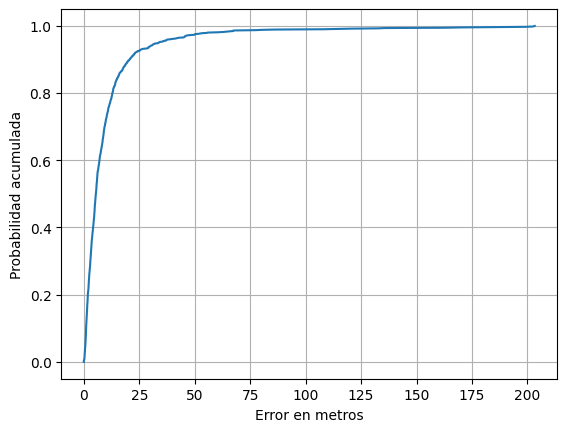

In [13]:
# instanciamos un objeto de la clase evaluador
uji1_final_evaluator = PerformanceEvaluator("UJI1")

# forzamos a arrays de np para poder hacer slicing por columnas
y_test_arr = uji1_y_test.values if hasattr(uji1_y_test, 'values') else np.asarray(uji1_y_test)
y_pred_arr = np.asarray(uji1_y_pred_best)

# extraemos y redondeamos las predicciones edificio (4) y el piso (3)
uji1_y_pred_labels = np.round(y_pred_arr[:, [4, 3]])

# calculamos todas las métricas de precisión con las predicciones sobre test del modelo final
# ahora debemos pasarle de forma explícita los 4 argumentos necesarios
uji1_final_metrics = uji1_final_evaluator.calculate_precision(
    y_true=y_test_arr[:, 0:2],
    y_pred=y_pred_arr[:, 0:2],
    building_floor_true=y_test_arr[:, [4, 3]],
    building_floor_pred=uji1_y_pred_labels
)

# imprimimos todas las métricas finales
print("MÉTRICAS FINALES DEL BASELINE DE UJI1")
for metrica, valor in uji1_final_metrics.items():
    print(f"{metrica}: {valor:.4f}")

# generamos la visualización de la curva de error
print("\nCurva de función de distribución acumulada UJI1")
uji1_final_evaluator.plot_cdf()